In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.ensemble import RandomForestClassifier



import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("Customer Complaints in Banking new v1.csv")

In [ ]:
df.head()

,Complaint ID,Date submitted,Date received,Submitted via,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer
0,4848023,2021-10-24,2021-10-27,Referral,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation
1,3621464,2020-04-24,2020-04-24,Web,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief
2,5818349,2022-07-27,2022-07-27,Web,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation
3,2473083,2017-05-01,2017-05-10,Postal mail,MD,Debt collection,Private student loan debt,False statements or representation,Attempted to collect wrong amount,0,Closed with explanation
4,5820224,2022-07-27,2022-07-28,Referral,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 62516
Columns : 11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Complaint ID                  62516 non-null  int64 
 1   Date submitted                62516 non-null  object
 2   Date received                 62516 non-null  object
 3   Submitted via                 62516 non-null  object
 4   State                         62516 non-null  object
 5   Product                       62516 non-null  object
 6   Sub-product                   62509 non-null  object
 7   Issue                         62516 non-null  object
 8   Sub-issue                     62514 non-null  object
 9   Company public response       62516 non-null  object
 10  Company response to consumer  62516 non-null  object
dtypes: int64(1), object(10)
memory usage: 5.2+ MB


In [ ]:
df.describe(include='all')

,Complaint ID,Date submitted,Date received,Submitted via,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer
count,6.251600e+04,62516,62516,62516,62516,62516,62509,62516,62514,62516,62516
unique,NaN,2308,2305,7,51,9,46,76,159,7,5
top,NaN,2023-07-12,2023-07-12,Web,CA,Checking or savings account,Checking account,Managing an account,0,Company has responded to the consumer and the ...,Closed with explanation
freq,NaN,183,184,45423,13709,24814,20768,15109,10856,60311,41044
mean,4.512642e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.442917e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.471340e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.254020e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.178582e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,5.771284e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

Complaint ID                    0
Date submitted                  0
Date received                   0
Submitted via                   0
State                           0
Product                         0
Sub-product                     7
Issue                           0
Sub-issue                       2
Company public response         0
Company response to consumer    0
dtype: int64

In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage

Complaint ID                    0.000000
Date submitted                  0.000000
Date received                   0.000000
Submitted via                   0.000000
State                           0.000000
Product                         0.000000
Sub-product                     0.011197
Issue                           0.000000
Sub-issue                       0.003199
Company public response         0.000000
Company response to consumer    0.000000
dtype: float64

In [ ]:
df.drop(columns=['Complaint ID'], inplace=True)

In [ ]:
print(df.columns)

Index(['Date submitted', 'Date received', 'Submitted via', 'State', 'Product',
       'Sub-product', 'Issue', 'Sub-issue', 'Company public response',
       'Company response to consumer'],
      dtype='object')


In [51]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Date submitted', 'Date received', 'Submitted via', 'State', 'Product',
       'Sub-product', 'Issue', 'Sub-issue', 'Company public response',
       'Company response to consumer', 'date submitted', 'data submitted',
       'Complaint_Length', 'target'],
      dtype='object')


In [52]:
#handling missing values
df.dropna(inplace=True)

In [53]:
print("Before :", df.shape)

df.drop_duplicates(inplace=True)

print("After :", df.shape)

Before : (58142, 14)
After : (58142, 14)


In [55]:
df.dtypes

Date submitted                  object
Date received                   object
Submitted via                   object
State                           object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Company public response         object
Company response to consumer    object
date submitted                   int64
data submitted                   int64
Complaint_Length                 int64
target                           int64
dtype: object

In [56]:
print(df.columns.tolist())

['Date submitted', 'Date received', 'Submitted via', 'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company response to consumer', 'date submitted', 'data submitted', 'Complaint_Length', 'target']


In [57]:
df['date submitted'] = df['Date received'].astype(str).apply(len)

In [58]:
df['data submitted'] = df[
    'Date received'
].apply(len)

In [59]:
df.columns = df.columns.str.strip()

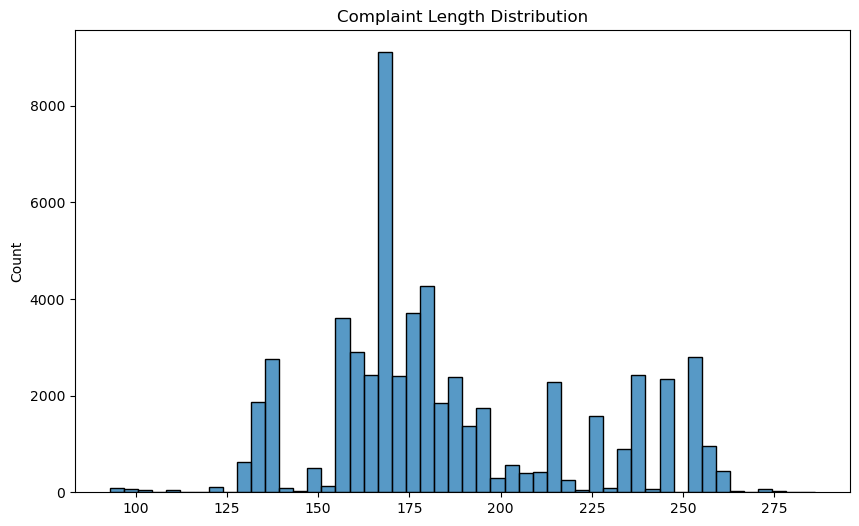

In [60]:
plt.figure(figsize=(10,6))

complaint_lengths = (
    df[['Issue', 'Sub-issue', 'Product', 'Company public response']]
    .fillna('')
    .astype(str)
    .apply(lambda row: len(' '.join(row)), axis=1)
)
sns.histplot(complaint_lengths, bins=50)

plt.title("Complaint Length Distribution")

plt.show()

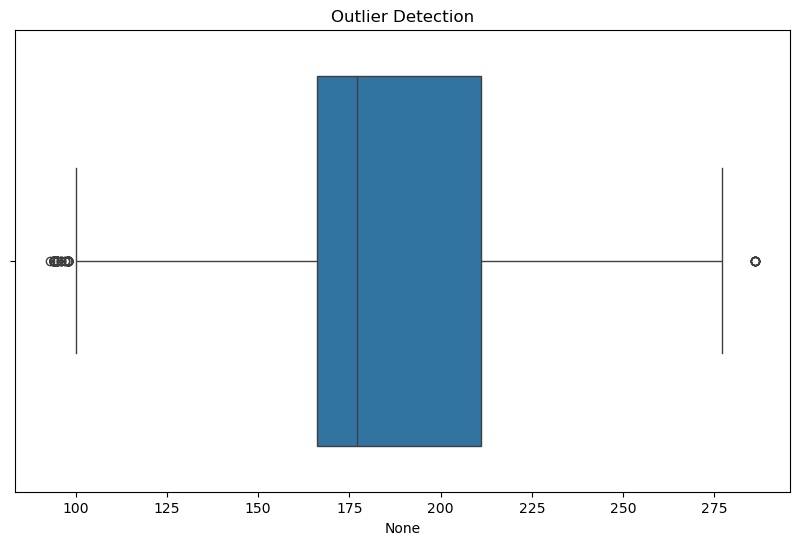

In [61]:
plt.figure(figsize=(10,6))

sns.boxplot(x=complaint_lengths)

plt.title("Outlier Detection")

plt.show()

In [62]:
complaint_lengths = (
    df[['Issue', 'Sub-issue', 'Product', 'Company public response']]
    .fillna('')
    .astype(str)
    .apply(lambda row: len(' '.join(row)), axis=1)
)

df['Complaint_Length'] = complaint_lengths.values

Q1 = df['Complaint_Length'].quantile(0.25)
Q3 = df['Complaint_Length'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Q3 = df['Complaint_Length'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound :", lower_bound)

print("Upper Bound :", upper_bound)

Lower Bound : 98.5
Upper Bound : 278.5
Lower Bound : 98.5
Upper Bound : 278.5


In [63]:
outliers = df[
    (df['Complaint_Length'] < lower_bound) |
    (df['Complaint_Length'] > upper_bound)
]

outliers.head()

,Date submitted,Date received,Submitted via,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,date submitted,data submitted,Complaint_Length,target
94,2017-05-02,2017-05-02,Web,IL,Checking or savings account,Checking account,Managing an account,Funds not handled or disbursed as instructed,0,Closed with explanation,10,10,94,1
148,2017-05-06,2017-05-09,Web,NV,Checking or savings account,Checking account,Problem caused by your funds being low,Overdrafts and overdraft fees,0,Closed with explanation,10,10,98,1
476,2017-06-13,2017-06-13,Referral,WI,Checking or savings account,Other banking product or service,Problem caused by your funds being low,Overdrafts and overdraft fees,0,Closed with monetary relief,10,10,98,2
1123,2017-06-29,2017-06-29,Web,GA,Checking or savings account,Checking account,Problem caused by your funds being low,Overdrafts and overdraft fees,0,Closed with monetary relief,10,10,98,2
1643,2017-09-06,2017-09-06,Web,DC,Vehicle loan or lease,Loan,Problems at the end of the loan or lease,Problem with paying off the loan,0,Closed with explanation,10,10,97,1


In [64]:
df = df[
    (df['Complaint_Length'] >= lower_bound) &
    (df['Complaint_Length'] <= upper_bound)
]

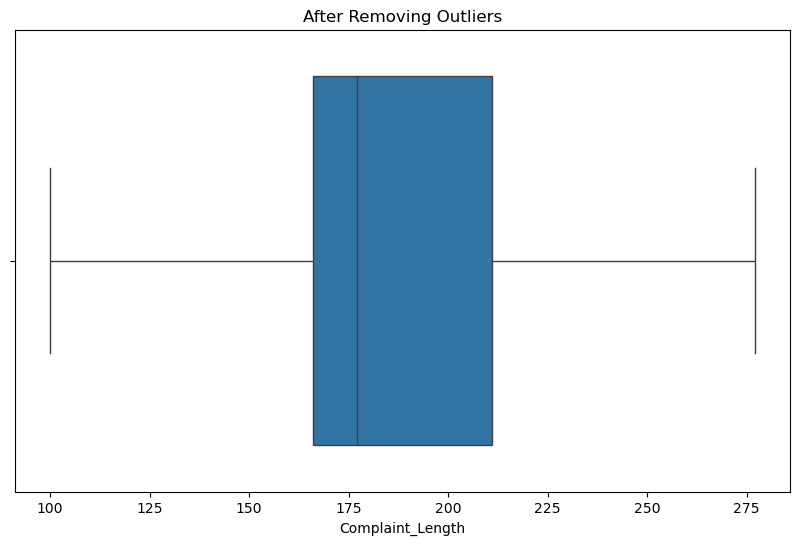

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['Complaint_Length'])

plt.title("After Removing Outliers")

plt.show()

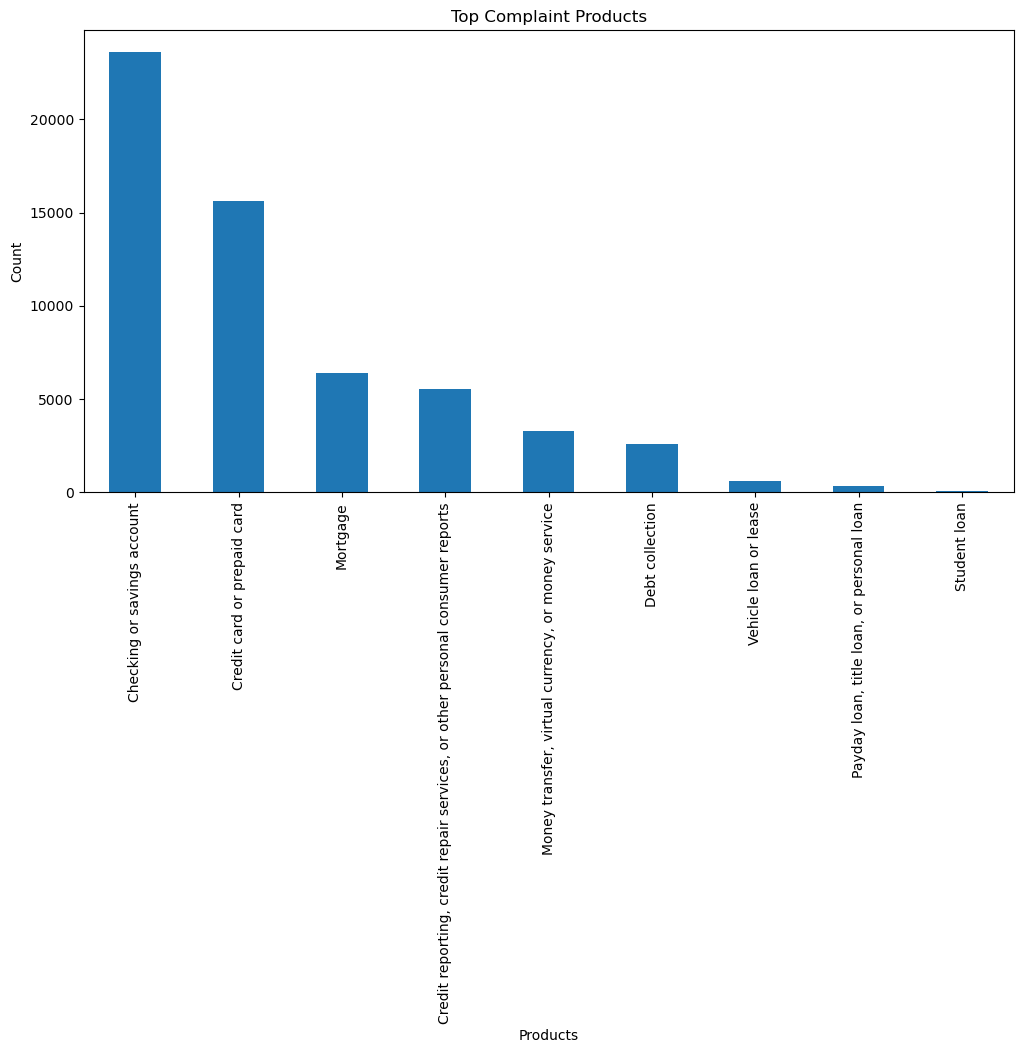

In [66]:
plt.figure(figsize=(12,6))

df['Product'].value_counts().head(10).plot(kind='bar')

plt.title("Top Complaint Products")

plt.xlabel("Products")

plt.ylabel("Count")

plt.show()

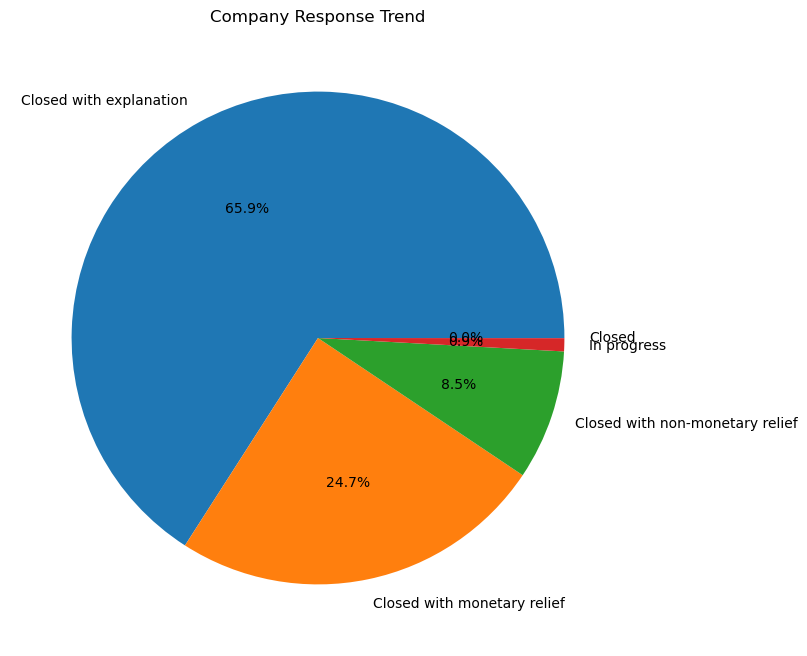

In [67]:
plt.figure(figsize=(8,8))

df['Company response to consumer'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Company Response Trend")

plt.show()

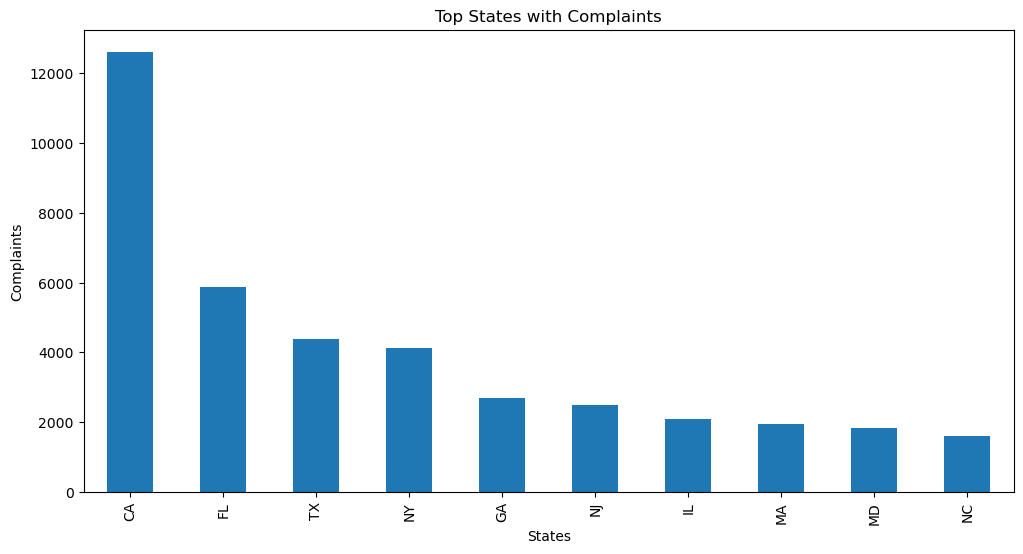

In [68]:
plt.figure(figsize=(12,6))

df['State'].value_counts().head(10).plot(kind='bar')

plt.title("Top States with Complaints")

plt.xlabel("States")

plt.ylabel("Complaints")

plt.show()

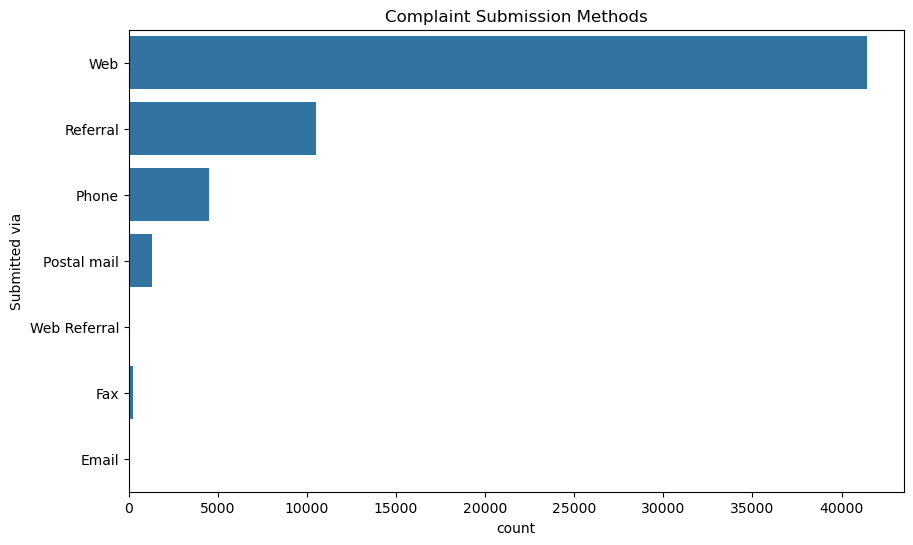

In [69]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, y='Submitted via')

plt.title("Complaint Submission Methods")

plt.show()

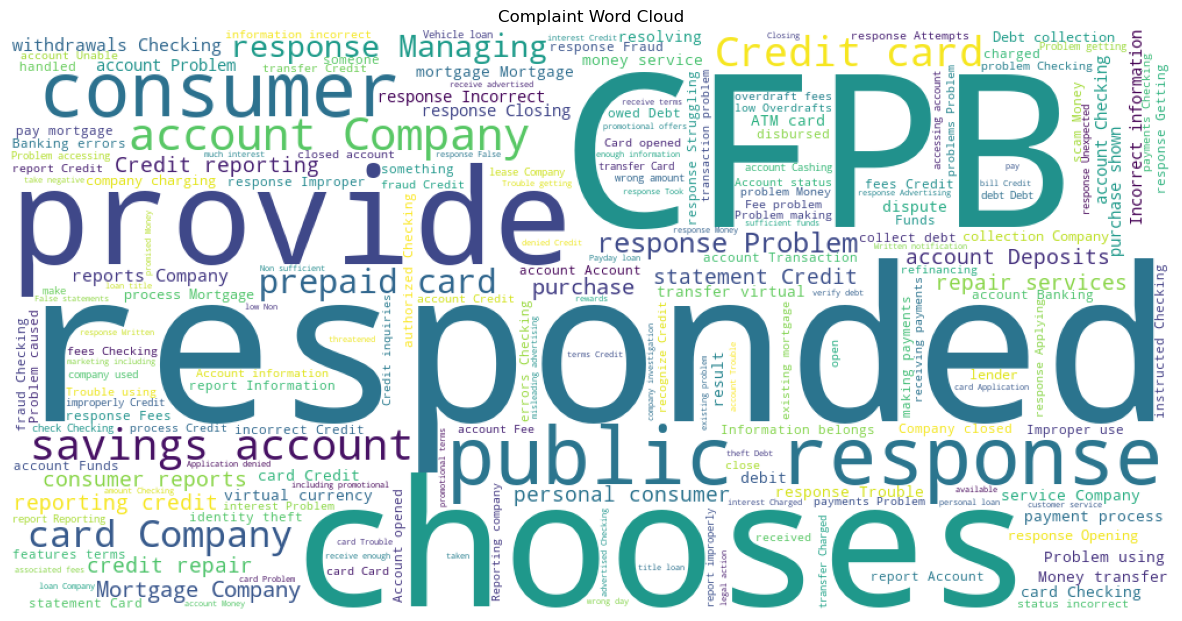

In [71]:
try:
    from wordcloud import WordCloud
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install wordcloud
    from wordcloud import WordCloud

text = " ".join(
    df[['Issue', 'Sub-issue', 'Product', 'Company public response']]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Complaint Word Cloud")

plt.show()

In [72]:
label_encoder = LabelEncoder()

df['target'] = label_encoder.fit_transform(
    df['Company response to consumer']
)

In [73]:
X = (
    df[['Issue', 'Sub-issue', 'Product', 'Company public response']]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

y = df['target']

y = df['target']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", len(X_train))

print("Testing Data :", len(X_test))

Training Data : 46403
Testing Data : 11601


In [75]:
model = Pipeline([

    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )),

    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [76]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [77]:
y_pred = model.predict(X_test)

In [78]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6800275838289802


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.69      0.94      0.80      7680
           2       0.57      0.15      0.23      2824
           3       0.54      0.14      0.23       999
           4       0.71      0.90      0.79        97

    accuracy                           0.68     11601
   macro avg       0.50      0.43      0.41     11601
weighted avg       0.65      0.68      0.61     11601



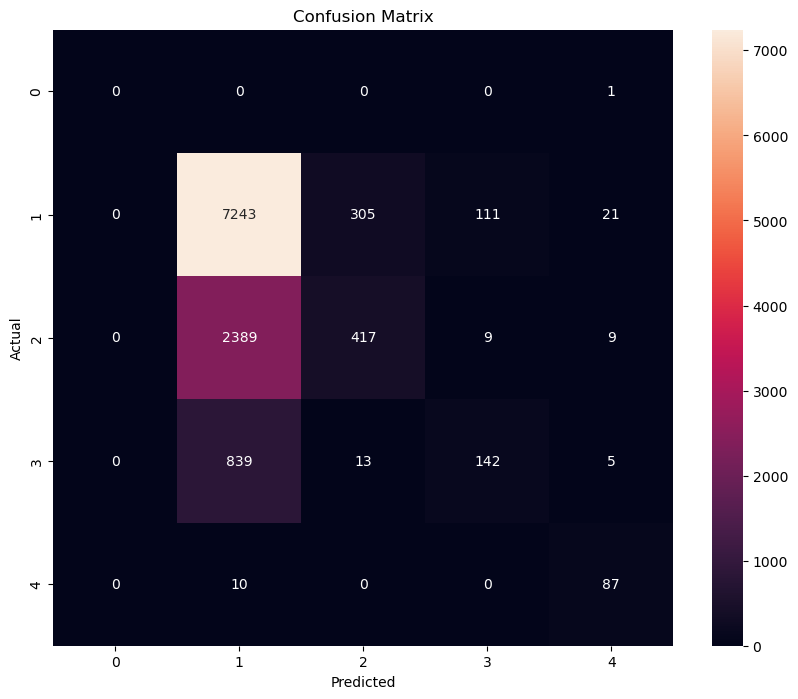

In [80]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [81]:
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

MSE : 0.5906387380398241


In [82]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 0.40824066890785277


In [83]:
rmse = np.sqrt(mse)

print("RMSE :", rmse)

RMSE : 0.7685302453643735


In [84]:
!pip install xgboost

from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )),
    ('classifier', XGBClassifier(
        eval_metric='mlogloss'
    ))
])

xgb_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )),
    ('classifier', XGBClassifier(
        eval_metric='mlogloss'
    ))
])


In [85]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [86]:
xgb_pred = xgb_model.predict(X_test)

In [87]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_accuracy)

XGBoost Accuracy : 0.6798551848978537


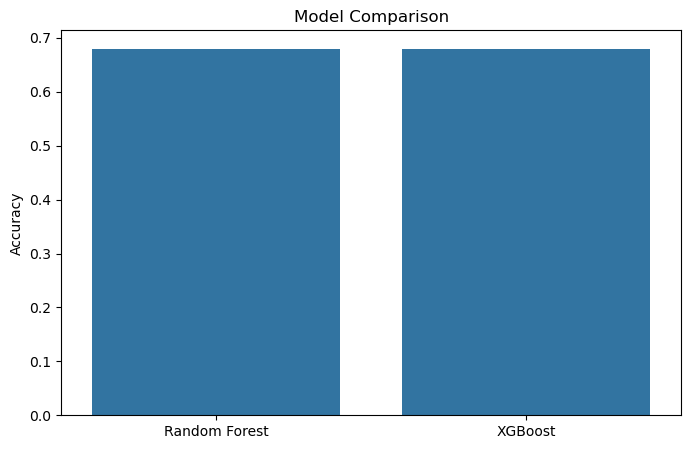

In [88]:
models = ['Random Forest', 'XGBoost']

accuracies = [accuracy, xgb_accuracy]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [89]:
sample = [
    "Bank charged extra fees from my account"
]

prediction = xgb_model.predict(sample)

result = label_encoder.inverse_transform(prediction)

print("Prediction :", result)

Prediction : ['In progress']


In [90]:
probability = xgb_model.predict_proba(sample)

print(probability)

[[1.7704673e-22 5.0046825e-16 7.7092794e-12 2.4057966e-13 1.0000000e+00]]


In [91]:
confidence = np.max(probability) * 100

print("Confidence :", confidence)

Confidence : 100.0


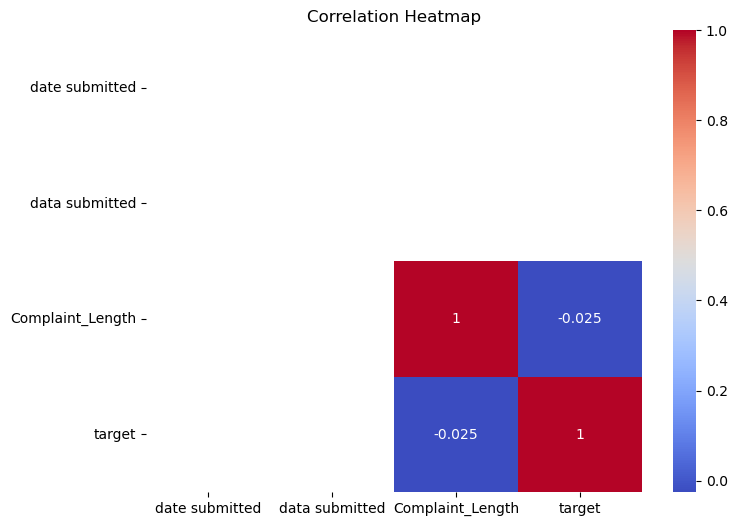

In [92]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [93]:
import joblib

joblib.dump(xgb_model, "customer_complaint_model.pkl")

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [94]:
model = joblib.load("customer_complaint_model.pkl")

encoder = joblib.load("label_encoder.pkl")

In [96]:

df.duplicated().sum()


np.int64(0)

In [97]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!
